# Demo 3 — Grating-evoked activity (1-D ring)

Drive a ring with a static sinusoidal "grating" input and look at the evoked
steady-state response as we change the connectivity parameters. The recurrent
gain (spectral radius) and the inhibition width both shape how strongly the
grating is amplified and sharpened.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in the repository folder (itself named
# "cortical_rate_model"), so we add its PARENT directory to the path.
# Walking up from the working directory lets this notebook run from the
# demos/ folder, from the repository root, or from anywhere inside the repo.
import sys, pathlib
_cwd = pathlib.Path.cwd()
for _p in (_cwd, *_cwd.parents):
    if _p.name == "cortical_rate_model" and (_p / "network.py").exists():
        sys.path.insert(0, str(_p.parent))
        break
else:
    raise RuntimeError("Could not locate the cortical_rate_model package directory.")


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

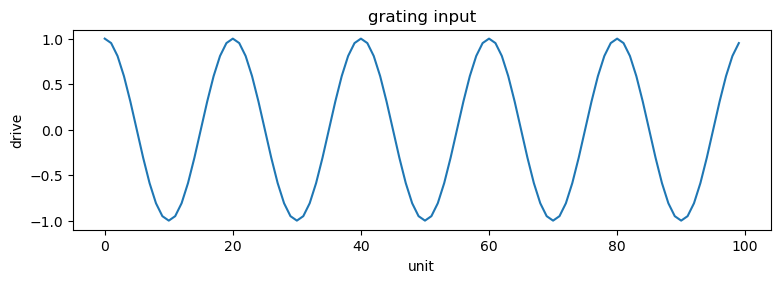

In [3]:
ring = Layout(100, periodic=True)
grating = inputs.oriented_grating(ring, wavelength=20.0, amplitude=1.0)
plt.figure(figsize=(9, 2.6)); plt.plot(grating)
plt.title("grating input"); plt.xlabel("unit"); plt.ylabel("drive"); plt.show()

## Sweep the recurrent gain (spectral radius)

Same Mexican-hat connectivity, increasing recurrent gain. Higher gain amplifies
the grating-aligned mode more strongly.

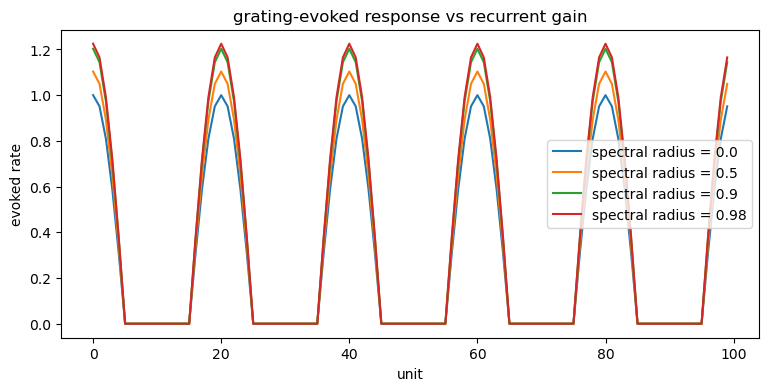

In [4]:
plt.figure(figsize=(9, 4))
for radius in [0.0, 0.5, 0.9, 0.98]:
    net = build_net("mexican_hat", ring, spectral_radius=max(radius, 1e-6),
                    sigma=6.0, inh_factor=2.0)
    r = net.steady_state(grating, n_steps=400).numpy()
    plt.plot(r, label=f"spectral radius = {radius}")
plt.xlabel("unit"); plt.ylabel("evoked rate")
plt.title("grating-evoked response vs recurrent gain"); plt.legend(); plt.show()

## Sweep the inhibition width

Fixed gain, varying `inh_factor` (how much broader inhibition is than
excitation). Broader inhibition sharpens the response.

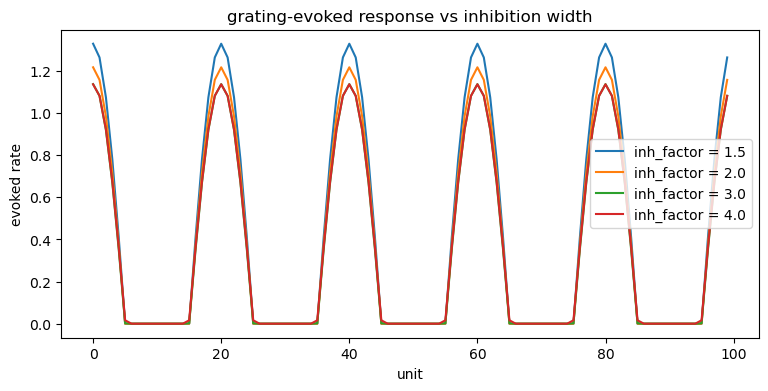

In [5]:
plt.figure(figsize=(9, 4))
for inh_factor in [1.5, 2.0, 3.0, 4.0]:
    net = build_net("mexican_hat", ring, spectral_radius=0.95,
                    sigma=6.0, inh_factor=inh_factor)
    r = net.steady_state(grating, n_steps=400).numpy()
    plt.plot(r, label=f"inh_factor = {inh_factor}")
plt.xlabel("unit"); plt.ylabel("evoked rate")
plt.title("grating-evoked response vs inhibition width"); plt.legend(); plt.show()